# Tarea - Simulación de Calls y Puts

**Parámetros base:** $S_0 = 100$, $K = 100$, $r = 5\%$, $\sigma = 20\%$, $T = 1$, $M = 10{,}000$

$$S_T = S_0 \exp\left[\left(r - \tfrac{\sigma^2}{2}\right)T + \sigma\sqrt{T}\,Z\right]$$

$$\text{Call} = e^{-rT}\,E[\max(S_T - K, 0)] \qquad \text{Put} = e^{-rT}\,E[\max(K - S_T, 0)]$$

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams['figure.figsize'] = (11, 5)


def bs_precios(S0, K, r, sigma, T):
    """Precio analítico Black-Scholes para call y put."""
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    call = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    put  = K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)
    return call, put


def mc_precios(S0, K, r, sigma, T, M=10_000, seed=42):
    """Precio Monte Carlo para call y put sobre la misma simulación."""
    np.random.seed(seed)
    Z  = np.random.normal(0, 1, M)
    ST = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    
    call = np.exp(-r*T) * np.maximum(ST - K, 0).mean()
    put  = np.exp(-r*T) * np.maximum(K - ST, 0).mean()
    return call, put, ST

## Parte 1 - Simulación y comparación con Black-Scholes

In [26]:
S0, K, r, sigma, T, M = 100, 100, 0.05, 0.20, 1, 10_000

call_mc, put_mc, ST = mc_precios(S0, K, r, sigma, T, M)
call_bs, put_bs     = bs_precios(S0, K, r, sigma, T)

comparacion = pd.DataFrame({
    'Opción': ['Call', 'Put'],
    'Monte Carlo': [call_mc, put_mc],
    'Black-Scholes': [call_bs, put_bs],
    'Diferencia': [abs(call_mc - call_bs), abs(put_mc - put_bs)],
    'P(terminar ITM)': [(ST > K).mean(), (ST < K).mean()] # ITM = IN THE MONEY
})

print(comparacion.round(4).to_string(index=False))

Opción  Monte Carlo  Black-Scholes  Diferencia  P(terminar ITM)
  Call      10.4502        10.4506      0.0004           0.5583
   Put       5.6017         5.5735      0.0282           0.4417


In [27]:
# Verificación de paridad put-call

izquierda = call_mc - put_mc
derecha   = S0 - K*np.exp(-r*T)

print(f"C - P            : {izquierda:.4f}")
print(f"S₀ - K·e^(-rT)   : {derecha:.4f}")
print(f"Diferencia       : {abs(izquierda - derecha):.4f}")

C - P            : 4.8485
S₀ - K·e^(-rT)   : 4.8771
Diferencia       : 0.0286


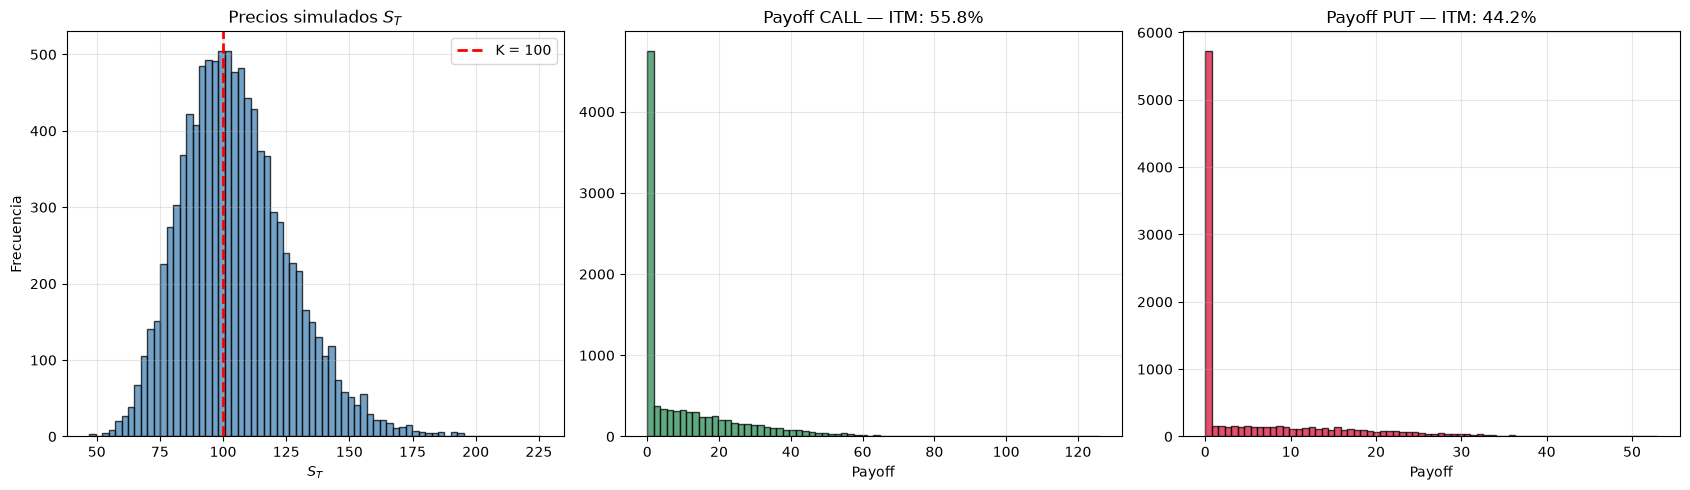

In [28]:
# Histogramas de payoffs

payoff_call = np.maximum(ST - K, 0)
payoff_put  = np.maximum(K - ST, 0)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].hist(ST, bins=70, color='steelblue', edgecolor='black', alpha=0.75)
axes[0].axvline(K, color='red', ls='--', lw=2, label=f'K = {K}')
axes[0].set_title('Precios simulados $S_T$')
axes[0].set_xlabel('$S_T$'); axes[0].set_ylabel('Frecuencia')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(payoff_call, bins=70, color='seagreen', edgecolor='black', alpha=0.75)
axes[1].set_title(f'Payoff CALL — ITM: {(ST>K).mean():.1%}')
axes[1].set_xlabel('Payoff'); axes[1].grid(alpha=0.3)

axes[2].hist(payoff_put, bins=70, color='crimson', edgecolor='black', alpha=0.75)
axes[2].set_title(f'Payoff PUT — ITM: {(ST<K).mean():.1%}')
axes[2].set_xlabel('Payoff'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Parte 2 y 3 - Sensibilidad y visualización

Se varía un parámetro a la vez manteniendo los demás en su valor base.


In [29]:
def analizar(parametro, valores, base=None):
    """Varía un parámetro y devuelve tabla + gráfica de call y put."""
    if base is None:
        base = dict(S0=100, K=100, r=0.05, sigma=0.20, T=1)
    
    filas = []
    for v in valores:
        p = base.copy()
        p[parametro] = v
        c, pu, _ = mc_precios(**p, M=10_000)
        c_bs, p_bs = bs_precios(**p)
        filas.append({parametro: v, 'Call MC': c, 'Put MC': pu,
                      'Call BS': c_bs, 'Put BS': p_bs})
    
    return pd.DataFrame(filas)


def graficar(tabla, parametro, etiqueta):
    plt.figure(figsize=(10, 5))
    plt.plot(tabla[parametro], tabla['Call MC'], marker='o', ms=8, lw=2.5,
             color='seagreen', label='Call')
    plt.plot(tabla[parametro], tabla['Put MC'], marker='s', ms=8, lw=2.5,
             color='crimson', label='Put')
    plt.xlabel(etiqueta); plt.ylabel('Precio de la opción')
    plt.title(f'Precio de la opción vs {etiqueta}')
    plt.legend(); plt.grid(alpha=0.3)
    plt.show()

 S0  Call MC  Put MC  Call BS  Put BS
 80   1.8795 17.0253   1.8594 16.9824
 90   5.0970 10.2456   5.0912 10.2142
100  10.4502  5.6017  10.4506  5.5735
110  17.6535  2.8079  17.6630  2.7859
120  26.1511  1.3084  26.1690  1.2920


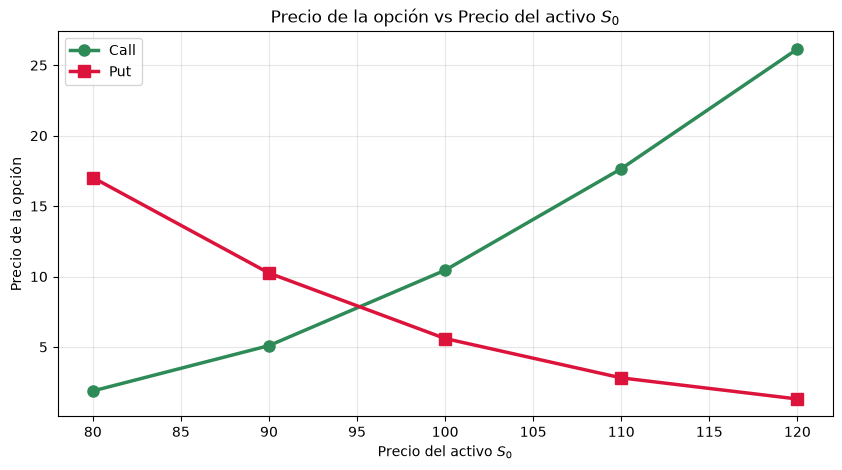

In [30]:
# PRECIO DEL ACTIVO S0

t_S0 = analizar('S0', [80, 90, 100, 110, 120])
print(t_S0.round(4).to_string(index=False))
graficar(t_S0, 'S0', 'Precio del activo $S_0$')

  K  Call MC  Put MC  Call BS  Put BS
 80  24.5731  0.7000  24.5888  0.6872
 90  16.6917  2.3310  16.6994  2.3101
100  10.4502  5.6017  10.4506  5.5735
110   6.0447 10.7086   6.0401 10.6753
120   3.2703 17.4465   3.2475 17.3950


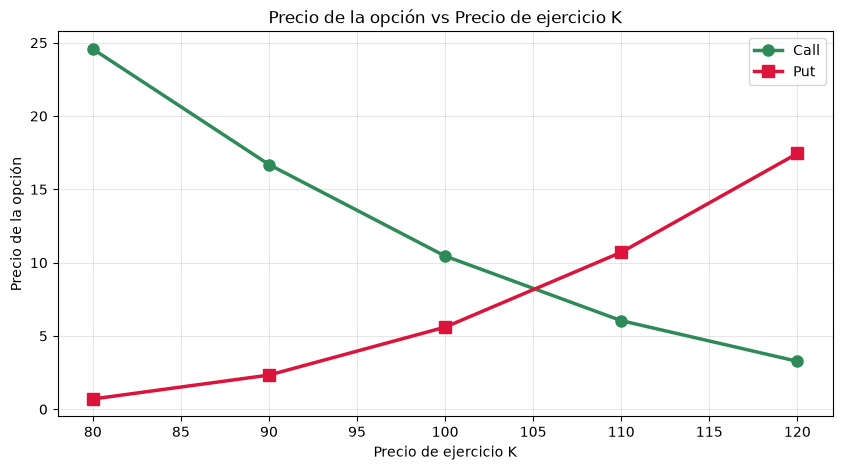

In [31]:
# STRIKE

t_K = analizar('K', [80, 90, 100, 110, 120])
print(t_K.round(4).to_string(index=False))
graficar(t_K, 'K', 'Precio de ejercicio K')

 sigma  Call MC  Put MC  Call BS  Put BS
   0.1   6.8004  1.9412   6.8050  1.9279
   0.2  10.4502  5.6017  10.4506  5.5735
   0.3  14.2369  9.3914  14.2313  9.3542
   0.4  18.0444 13.1932  18.0230 13.1459
   0.5  21.8357 16.9693  21.7926 16.9155


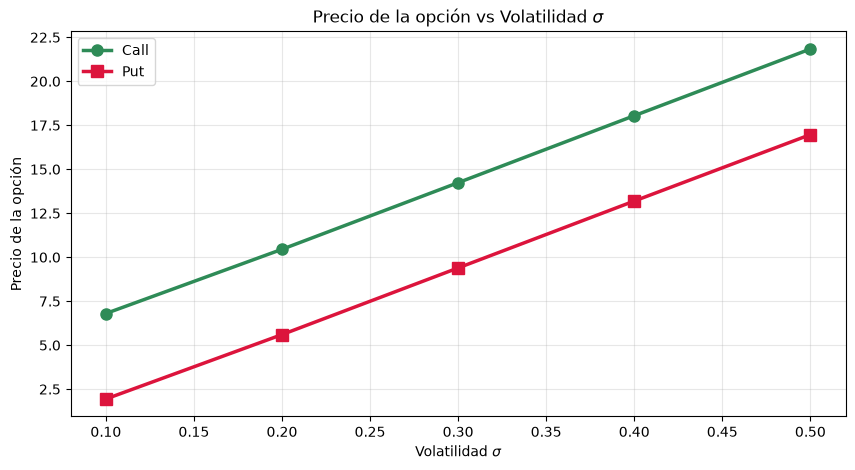

In [32]:
# VOLATILIDAD

t_sigma = analizar('sigma', [0.10, 0.20, 0.30, 0.40, 0.50])
print(t_sigma.round(4).to_string(index=False))
graficar(t_sigma, 'sigma', 'Volatilidad $\\sigma$')

   T  Call MC  Put MC  Call BS  Put BS
0.25   4.6133  3.3890   4.6150  3.3728
0.50   6.8874  4.4417   6.8887  4.4197
1.00  10.4502  5.6017  10.4506  5.5735
1.50  13.4430  6.2483  13.4429  6.2173
2.00  16.1279  6.6433  16.1268  6.6105


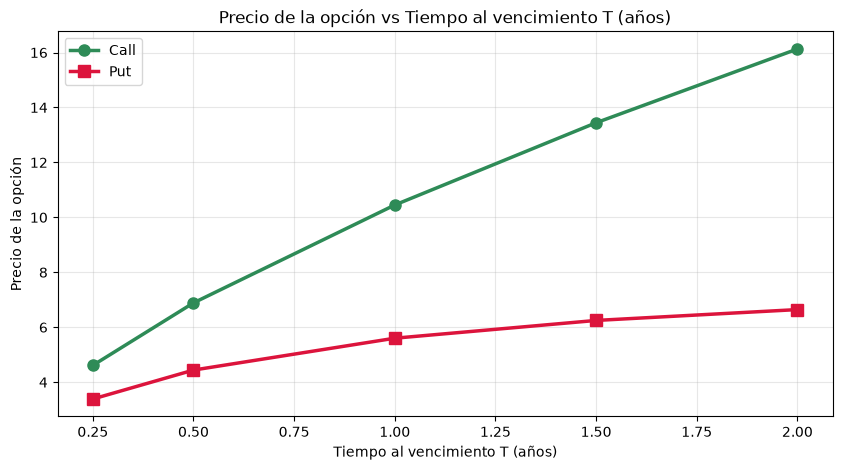

In [33]:
# TIEMPO

t_T = analizar('T', [0.25, 0.5, 1, 1.5, 2])
print(t_T.round(4).to_string(index=False))
graficar(t_T, 'T', 'Tiempo al vencimiento T (años)')

   r  Call MC  Put MC  Call BS  Put BS
0.05  10.4502  5.6017  10.4506  5.5735
0.10  13.2649  3.7772  13.2697  3.7534
0.15  16.3478  2.4472  16.3560  2.4268
0.20  19.6170  1.5187  19.6299  1.5030


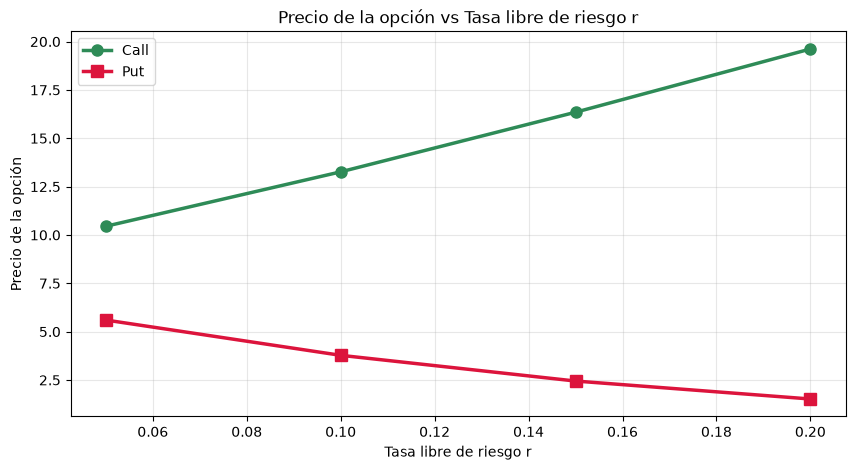

In [34]:
# TASA LIBRE DE RIESGO r

t_r = analizar('r', [0.05, 0.10, 0.15, 0.20])
print(t_r.round(4).to_string(index=False))
graficar(t_r, 'r', 'Tasa libre de riesgo r')

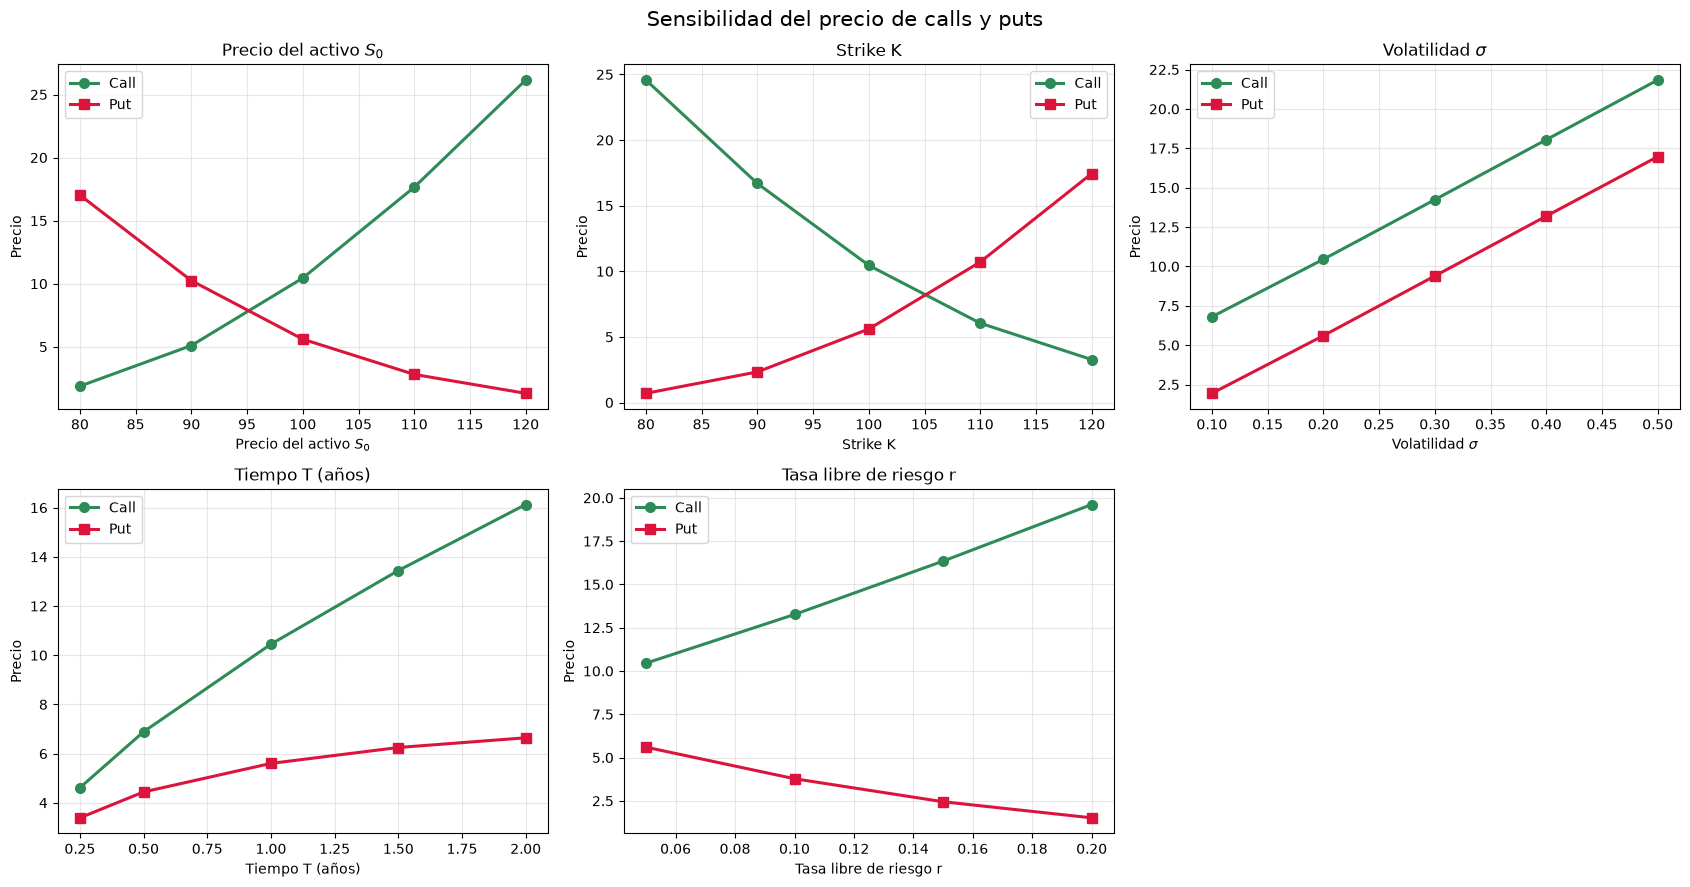

In [35]:
# RESUMEN

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

datos = [
    (t_S0,    'S0',    'Precio del activo $S_0$',   axes[0,0]),
    (t_K,     'K',     'Strike K',                  axes[0,1]),
    (t_sigma, 'sigma', 'Volatilidad $\\sigma$',     axes[0,2]),
    (t_T,     'T',     'Tiempo T (años)',           axes[1,0]),
    (t_r,     'r',     'Tasa libre de riesgo r',    axes[1,1]),
]

for tabla, param, etiq, ax in datos:
    ax.plot(tabla[param], tabla['Call MC'], marker='o', ms=7, lw=2.2,
            color='seagreen', label='Call')
    ax.plot(tabla[param], tabla['Put MC'], marker='s', ms=7, lw=2.2,
            color='crimson', label='Put')
    ax.set_xlabel(etiq); ax.set_ylabel('Precio')
    ax.set_title(etiq)
    ax.legend(); ax.grid(alpha=0.3)

axes[1,2].axis('off')
plt.suptitle('Sensibilidad del precio de calls y puts', fontsize=15)
plt.tight_layout()
plt.show()

## Parte 4. Interpretación

### Precio del activo

**¿Por qué una call aumenta cuando aumenta el precio de la acción?**

Una call es el derecho a comprar la acción a 100. Ese derecho vale más cuando la
acción ya está cerca o por encima de ese precio, porque el escenario en el que
sirve deja de ser una posibilidad remota y se vuelve el escenario probable.

Con la acción en 80 estás comprando la posibilidad de que suba 25% en un año
solo para empezar a ganar algo. Es una apuesta lejana y por eso barata: 1.88.
Con la acción en 120 ya vas ganando 20 pesos si el vencimiento fuera hoy, y lo
único que compras adicionalmente es protección contra que se caiga. El derecho
vale 26.15.

Lo importante es que el aumento no es proporcional. De 80 a 90 el precio sube
3.2 pesos, de 110 a 120 sube 8.5. Conforme la acción se acerca y rebasa el
strike, cada peso de subida se transmite cada vez más completo al precio de la
opción. En 80 la call apenas reacciona porque casi seguro no va a servir; en 120
se mueve casi peso por peso con la acción, porque ya se comporta como si
tuvieras la acción misma.

**¿Por qué una put se comporta de manera distinta?**

La put es el derecho a vender a 100, o sea un seguro contra caídas. Un seguro
vale más cuando el siniestro que cubre es probable, y menos cuando parece lejano.

Con la acción en 80 el siniestro ya ocurrió: la put vale 17.03 porque
efectivamente puedes vender en 100 algo que cuesta 80. Con la acción en 120 estás
pagando por protección contra una caída de más del 17%, que en un año con 20% de
volatilidad no es imposible pero sí improbable. Vale 1.31.

Es exactamente el mismo razonamiento que la call, pero con el evento invertido.
Por eso las dos curvas se cruzan: describen las dos mitades del mismo riesgo.
Quien compra la call apuesta a que sube, quien compra la put se protege de que
baje, y ambos están mirando la misma distribución de precios futuros desde lados
opuestos.

### Volatilidad

**¿Por qué una mayor incertidumbre aumenta el valor de la opción?**

Este es el resultado menos intuitivo de toda la tarea, porque sube el precio de
la call y de la put al mismo tiempo. Al pasar de 10% a 50% de volatilidad la call
va de 6.80 a 21.84 y la put de 1.94 a 16.97. Normalmente más incertidumbre es
algo malo, aquí es algo por lo que se paga más.

La clave está en que la opción no te obliga a nada. Si compras la acción y se
desploma, pierdes todo lo que cayó. Si compras la call y se desploma, pierdes la
prima y nada más, porque simplemente no ejerces. La opción te da la parte buena
de la incertidumbre y te corta la parte mala.

Piénsalo con números. Con volatilidad baja, la acción probablemente termine entre
85 y 120: la call gana como mucho 20 y casi nunca vale cero. Con volatilidad alta
puede terminar entre 40 y 250. El escenario de 40 no te duele más que el de 85,
en los dos pierdes solo la prima. Pero el escenario de 250 te paga 150 en lugar
de 20. Al ampliar el rango de posibilidades solo se amplía lo que puedes ganar,
no lo que puedes perder.

Por eso mismo funciona igual para la put. Ampliar la incertidumbre hace más
probables las caídas fuertes, que es donde la put paga, sin que las subidas
fuertes le cuesten nada extra a su comprador.

Esto explica algo que se ve en el mercado: los precios de opciones se disparan
antes de reportes trimestrales, elecciones o decisiones de tasas, aunque nadie
sepa hacia dónde se va a mover el precio. No se está pagando por una dirección,
se está pagando por la magnitud del movimiento.

### Tiempo

**¿Siempre es deseable tener más tiempo?**

Para el comprador, casi siempre. Más tiempo son más oportunidades de que el
precio llegue a donde le conviene, y su pérdida sigue siendo la misma prima sin
importar cuánto dure el contrato. La call va de 4.61 a tres meses hasta 16.13 a
dos años.

Pero el beneficio se agota rápido. De 0.25 a 1 año el precio se duplica con
creces; de 1 a 2 años, con el mismo año adicional, apenas sube 5.7 pesos. La
razón es que el precio no se dispersa proporcionalmente al tiempo sino a su raíz
cuadrada: cuadruplicar el plazo solo duplica el rango de precios posibles. El
tiempo compra incertidumbre, pero cada vez más cara.

En la put el efecto se estanca todavía antes: de 5.60 a 6.64 entre uno y dos
años. Aquí hay dos fuerzas peleando. Más tiempo hace más probable una caída
fuerte, lo cual la beneficia, pero también significa que los 100 pesos que
eventualmente cobraría llegarían mucho más tarde, y ese dinero futuro vale menos
hoy. Las dos cosas casi se cancelan. Con tasas suficientemente altas, una put
puede llegar a valer menos entre más tiempo tenga.

**¿Para quién resulta favorable?**

Los dos lados ven el tiempo de forma opuesta y esa es la esencia del negocio de
vender opciones.

El comprador quiere que pase algo, y el tiempo es su ventana para que pase. El
vendedor ya cobró la prima el primer día y lo único que puede pasarle es que el
mercado se mueva en su contra: para él, cada día que pasa sin que se mueva es un
día de ganancia asegurada.

Por eso el paso del tiempo, con todo lo demás igual, transfiere valor del
comprador al vendedor. Una opción vale menos mañana que hoy, y esa pérdida se
acelera conforme se acerca el vencimiento, porque queda menos margen para que las
cosas cambien.

### Strike

**¿Cómo modifica el strike la probabilidad de terminar in-the-money?**

El strike es el nivel que el precio tiene que cruzar para que la opción sirva.
Moverlo es mover la meta.

Para una call, subir el strike es pedirle más a la acción. Con strike 80, la
acción solo necesita no caer más del 20% y la opción sirve: eso pasa en 89.6% de
los escenarios simulados. Con strike 120 hay que exigirle una subida de más del
20% en el año, que solo ocurre en 22.0% de los casos.

Pero la probabilidad no cuenta toda la historia. Con strike alto, además de que
se gana menos veces, se gana menos cada vez, porque a la ganancia se le resta un
número mayor. Los escenarios ganadores pasan de pagar 28.83 en promedio con
strike 80 a 15.62 con strike 120. Los dos efectos van en la misma dirección y por
eso el precio se desploma de 24.57 a 3.27.

Para la put es la lectura inversa: subir el strike es contratar un seguro con
mejor cobertura. Un seguro que te garantiza vender en 120 vale mucho más que uno
que te garantiza vender en 80, y por eso su precio sube de 0.70 a 17.45.

Hay un detalle que vale la pena notar. Con strike 80 la call vale 24.57 pero solo
20 de esos pesos corresponden a la ventaja que ya tienes hoy; los otros 4.57 son
lo que vale la posibilidad de que suba todavía más. Ese excedente es máximo
cuando el strike coincide con el precio actual, donde el resultado está
genuinamente en el aire y hay más incertidumbre que resolver.

**Definir in-the-money**

Una opción está in-the-money cuando ejercerla en ese momento dejaría ganancia.
Es decir, cuando el derecho que otorga es mejor que lo que se consigue
directamente en el mercado.

Para una call eso ocurre cuando el precio de la acción está por encima del
strike, porque el derecho a comprar barato vale algo. Para una put es al revés,
cuando el precio está por debajo del strike, porque el derecho a vender caro es
el que vale.

Cuando el precio y el strike coinciden se dice que está at-the-money, y cuando
la opción no serviría de ejercerse hoy está out-of-the-money. Una opción
out-of-the-money no vale cero: sigue teniendo precio porque queda tiempo para
que la situación

## Parte 5. Comparación con el mercado

**¿Cuál parámetro consideras más importante monitorear?**

La volatilidad, y la razón se ve en los propios resultados de la tarea.

Empecemos por descartar los demás. El strike y el tiempo al vencimiento no se
monitorean: vienen escritos en el contrato y no cambian nunca. La tasa libre de
riesgo se mueve poco y de forma anunciada; entre 5% y 20% la call se duplica,
pero nadie espera que las tasas se cuadrupliquen de un trimestre a otro. Quedan
el precio del activo y la volatilidad.

El precio del activo es lo primero que uno miraría, y no está mal: es lo que
mueve la posición día a día. Pero tiene una característica que lo vuelve menos
crítico de lo que parece. Todo el mundo lo ve al mismo tiempo, en la misma
pantalla, sin ambigüedad. Nadie se equivoca sobre cuánto vale una acción. Y si
uno tiene calls y puts, el movimiento del precio afecta a las dos posiciones en
direcciones opuestas, así que hasta cierto punto se compensan solas.

La volatilidad no tiene ninguna de esas ventajas.

Lo primero es que no se puede leer en ninguna parte. El precio de la acción está
publicado, el strike está en el contrato, la fecha de vencimiento también, la
tasa la fija el banco central. La volatilidad hay que estimarla, y dos personas
razonables usando datos distintos van a llegar a números distintos. En la tarea,
la diferencia entre suponer 20% y suponer 30% cambia el precio de la call de
10.45 a 14.24: casi 4 pesos de diferencia sobre un contrato que vale 10, y ambos
supuestos son perfectamente defendibles con datos históricos. Ese es el único
lugar del modelo donde uno puede estar seriamente equivocado sin darse cuenta.

Lo segundo es que golpea a todas las posiciones al mismo tiempo. Cuando la
volatilidad pasó de 10% a 50%, la call subió de 6.80 a 21.84 y la put de 1.94 a
16.97. Las dos hacia arriba. Esto significa que no hay forma de armarse una
cartera de opciones que quede naturalmente protegida contra cambios de
volatilidad, cosa que sí se puede hacer contra movimientos de precio. Un
portafolio de opciones tiene una exposición a volatilidad que se acumula en vez
de cancelarse.

Lo tercero, y quizá lo más importante, es que es el supuesto más débil del
modelo. Black-Scholes asume que la volatilidad es constante durante toda la vida
del contrato, y eso simplemente no es cierto. Los mercados pasan meses tranquilos
y luego se sacuden en cuestión de días. El propio mercado lo reconoce: si de
verdad creyera en volatilidad constante, todas las opciones sobre la misma acción
implicarían el mismo número, y en la práctica las opciones muy fuera del dinero
implican volatilidades bastante más altas. Ese patrón, conocido como sonrisa de
volatilidad, es la manera en que el mercado corrige un supuesto en el que no cree.

Vale aclarar que la respuesta cambia según quién pregunte. Alguien que compra una
call porque cree que la empresa va a reportar buenos resultados está apostando a
la dirección, y para él lo que importa es el precio de la acción. Pero quien vive
de operar opciones normalmente neutraliza esa exposición direccional y lo que le
queda es exactamente volatilidad. Para él, la volatilidad no es un parámetro a
monitorear: es el activo con el que trabaja.

En resumen: el precio de la acción determina cuánto se gana o se pierde hoy,
pero la volatilidad determina cuánto vale la opción en primer lugar. Y es el
único de los cinco parámetros donde uno puede estar equivocado, donde el error
afecta toda la cartera a la vez, y donde el modelo mismo hace la suposición más
frágil.